In [74]:
# !pip install -r requirements.txt

In [75]:
RANDOM_STATE = 42
FORECAST_HORIZON = 3

In [76]:
import warnings
warnings.filterwarnings('ignore')

In [77]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [79]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import IsolationForest

In [80]:
from prophet import Prophet
import xgboost as xgb
model_xgb = xgb.XGBRegressor()

In [81]:
df = pd.read_csv("data/train.csv")

df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)

df['Sales'] = pd.to_numeric(df['Sales'], errors='coerce')
df = df.dropna(subset=['Order Date', 'Sales'])

df = df.sort_values('Order Date')
df.set_index('Order Date', inplace=True)

In [82]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
DatetimeIndex: 9800 entries, 2015-01-03 to 2018-12-30
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   str           
 2   Ship Date      9800 non-null   datetime64[us]
 3   Ship Mode      9800 non-null   str           
 4   Customer ID    9800 non-null   str           
 5   Customer Name  9800 non-null   str           
 6   Segment        9800 non-null   str           
 7   Country        9800 non-null   str           
 8   City           9800 non-null   str           
 9   State          9800 non-null   str           
 10  Postal Code    9789 non-null   float64       
 11  Region         9800 non-null   str           
 12  Product ID     9800 non-null   str           
 13  Category       9800 non-null   str           
 14  Sub-Category   9800 non-null   str           
 15  Product Name  

,Row ID,Ship Date,Postal Code,Sales
count,9800.000000,9800,9789.000000,9800.000000
mean,4900.500000,2017-05-05 04:17:52.653061,55273.322403,230.769059
min,1.000000,2015-01-07 00:00:00,1040.000000,0.444000
25%,2450.750000,2016-05-27 18:00:00,23223.000000,17.248000
50%,4900.500000,2017-06-29 00:00:00,58103.000000,54.490000
75%,7350.250000,2018-05-19 00:00:00,90008.000000,210.605000
max,9800.000000,2019-01-05 00:00:00,99301.000000,22638.480000
std,2829.160653,NaN,32041.223413,626.651875


In [83]:
df['Shipping Delay'] = (df['Ship Date'] - df.index).dt.days

monthly_sales = df['Sales'].resample('ME').sum()
weekly_sales = df['Sales'].resample('W').sum()

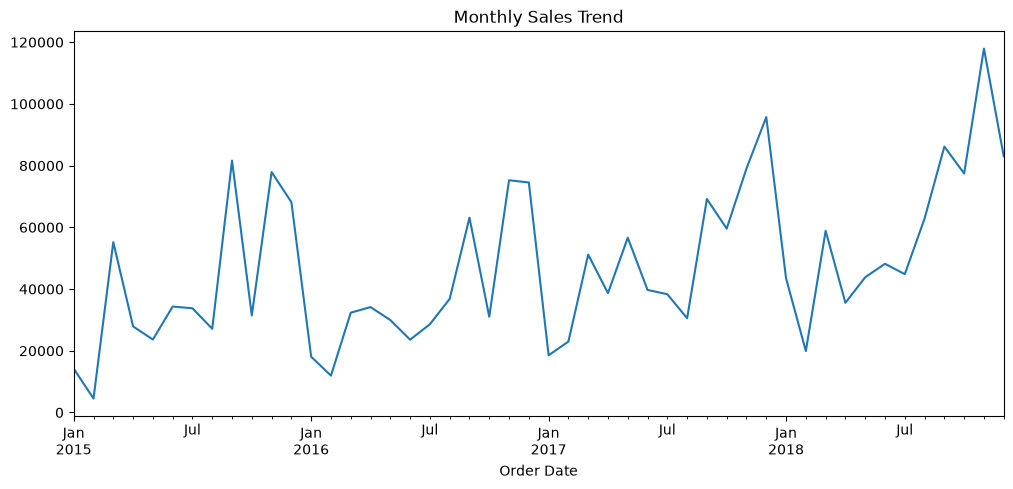

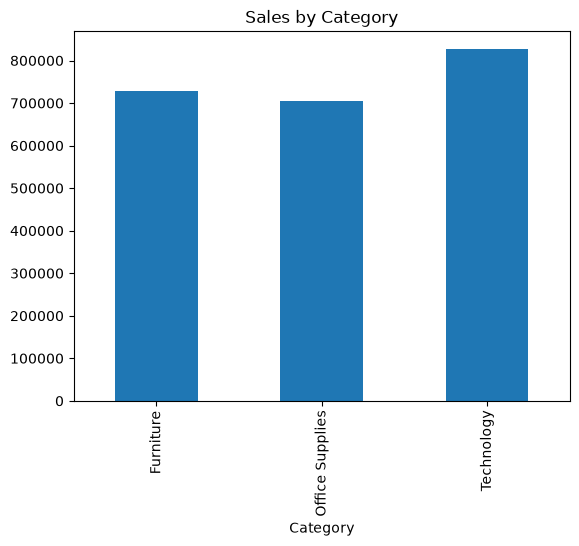

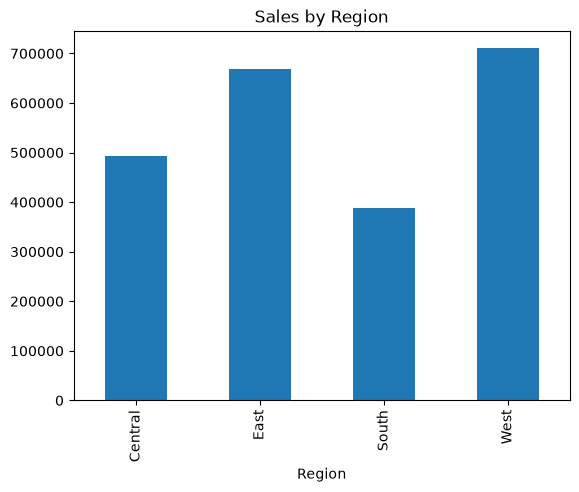

<Figure size 640x480 with 0 Axes>

In [84]:
plt.figure(figsize=(12,5))
monthly_sales.plot(title="Monthly Sales Trend")
plt.show()
plt.savefig("charts/monthly_sales_trend.png")

df.groupby('Category')['Sales'].sum().plot(kind='bar', title="Sales by Category")
plt.show()
plt.savefig("charts/sales_by_category.png")

df.groupby('Region')['Sales'].sum().plot(kind='bar', title="Sales by Region")
plt.show()
plt.savefig("charts/sales_by_region.png")

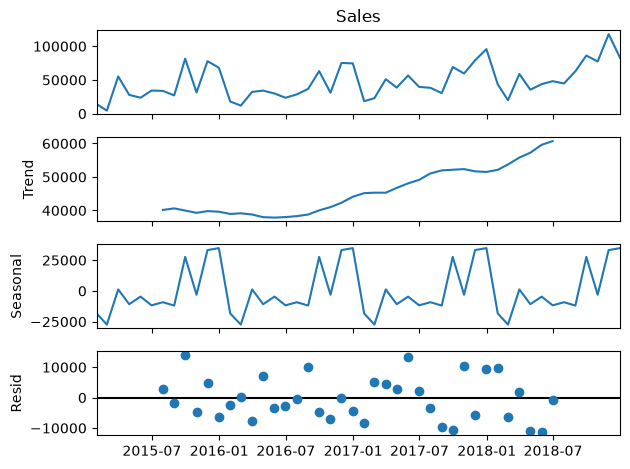

<Figure size 640x480 with 0 Axes>

In [85]:
decomp = seasonal_decompose(monthly_sales, model='additive')
decomp.plot()
plt.show()
plt.savefig("charts/seasonal_decomposition.png")

In [86]:
result = adfuller(monthly_sales)
print("P-value:", result[1])

P-value: 0.00027791039276670623


In [87]:
train = monthly_sales[:-12]
test = monthly_sales[-12:]

In [88]:
sarima = SARIMAX(train, order=(1,1,1), seasonal_order=(1,1,1,12))
sarima_fit = sarima.fit()

sarima_pred = sarima_fit.forecast(steps=len(test))

sarima_mae, sarima_rmse, sarima_mape = evaluate_model(
    test.values, sarima_pred
)

In [89]:
prophet_df = train.reset_index()
prophet_df.columns = ['ds', 'y']

model = Prophet()
model.fit(prophet_df)

future = model.make_future_dataframe(periods=len(test), freq='ME')
forecast = model.predict(future)

prophet_pred = forecast['yhat'].iloc[-len(test):].values

prophet_mae, prophet_rmse, prophet_mape = evaluate_model(
    test.values, prophet_pred
)

21:21:18 - cmdstanpy - INFO - Chain [1] start processing
21:21:18 - cmdstanpy - INFO - Chain [1] done processing


In [90]:
ts_df = monthly_sales.to_frame(name='y')

ts_df['lag1'] = ts_df['y'].shift(1)
ts_df['lag2'] = ts_df['y'].shift(2)
ts_df['month'] = ts_df.index.month

ts_df = ts_df.dropna()

train_ml = ts_df[:-12]
test_ml = ts_df[-12:]

X_train = train_ml.drop('y', axis=1)
y_train = train_ml['y']

X_test = test_ml.drop('y', axis=1)
y_test = test_ml['y']

# model_xgb = xgb.XGBRegressor()
model_xgb = xgb.XGBRegressor(n_estimators=300, max_depth=3)
model_xgb.fit(X_train, y_train)

xgb_pred = model_xgb.predict(X_test)

xgb_mae, xgb_rmse, xgb_mape = evaluate_model(y_test, xgb_pred)

In [91]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return mae, rmse, mape

In [92]:
sarima_forecast = sarima_fit.forecast(steps=FORECAST_HORIZON)

In [93]:
best_model = comparison.loc[comparison['RMSE'].idxmin()]
print(best_model)

Model         Prophet
MAE       9839.833495
RMSE     14133.088062
Name: 1, dtype: object


In [94]:
future_full = model.make_future_dataframe(periods=FORECAST_HORIZON, freq='ME')
prophet_forecast = model.predict(future_full).iloc[-FORECAST_HORIZON:]

In [95]:
last_row = X_test.iloc[-1:].copy()
xgb_forecast = []

for _ in range(FORECAST_HORIZON):
    pred = model_xgb.predict(last_row)[0]
    xgb_forecast.append(pred)
    
    # shift lag features
    last_row['lag2'] = last_row['lag1']
    last_row['lag1'] = pred

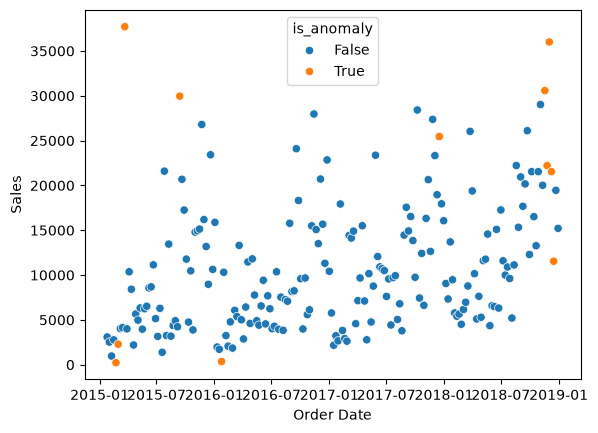

<Figure size 640x480 with 0 Axes>

In [96]:
weekly_df = weekly_sales.to_frame(name='Sales')

weekly_df['rolling_mean'] = weekly_df['Sales'].rolling(4).mean()
weekly_df = weekly_df.dropna()

iso = IsolationForest(contamination=0.05)
weekly_df['anomaly'] = iso.fit_predict(weekly_df[['Sales','rolling_mean']])

weekly_df['is_anomaly'] = weekly_df['anomaly'] == -1

sns.scatterplot(x=weekly_df.index, y=weekly_df['Sales'], hue=weekly_df['is_anomaly'])
plt.show()
plt.savefig("charts/anomaly_detection.png")

In [97]:
cluster_df = df.groupby('Customer ID').agg({
    'Sales':['sum','mean','count']
})

cluster_df.columns = ['total','avg','orders']

scaler = StandardScaler()
scaled = scaler.fit_transform(cluster_df)

kmeans = KMeans(n_clusters=3, random_state=42)
cluster_df['cluster'] = kmeans.fit_predict(scaled)

cluster_df.head()

,total,avg,orders,cluster
Customer ID,,,,
AA-10315,5563.560,505.778182,11,2
AA-10375,1056.390,70.426000,15,1
AA-10480,1790.512,149.209333,12,1
AA-10645,5086.935,282.607500,18,0
AB-10015,886.156,147.692667,6,1


In [98]:
final_model = SARIMAX(monthly_sales, order=(1,1,1), seasonal_order=(1,1,1,12))
final_fit = final_model.fit()

forecast = final_fit.forecast(FORECAST_HORIZON)

forecast_df = forecast.to_frame(name='Forecast')
forecast_df.index = pd.date_range(
    start=monthly_sales.index[-1] + pd.DateOffset(months=1),
    periods=FORECAST_HORIZON,
    freq='ME'
)
forecast_df.reset_index(inplace=True)
forecast_df.columns = ['Date', 'Forecast']

forecast_df.to_csv("data/forecast.csv", index=False)

In [99]:
print("SARIMA:", sarima_mae, sarima_rmse, sarima_mape)
print("Prophet:", prophet_mae, prophet_rmse, prophet_mape)
print("XGBoost:", xgb_mae, xgb_rmse, xgb_mape)

SARIMA: 17267.939104140736 19805.405891745133 41.61298306397249
Prophet: 9839.833495343222 14133.088061977358 15.668704448266539
XGBoost: 18673.813077864583 21597.7807412761 29.012275994878205


In [100]:
comparison_df = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],

    "MAE": [sarima_mae, prophet_mae, xgb_mae],
    "RMSE": [sarima_rmse, prophet_rmse, xgb_rmse],
    "MAPE (%)": [sarima_mape, prophet_mape, xgb_mape],

    "Forecast Month 1": [
        sarima_forecast.iloc[0],
        prophet_forecast['yhat'].values[0],
        xgb_forecast[0]
    ],

    "Forecast Month 2": [
        sarima_forecast.iloc[1],
        prophet_forecast['yhat'].values[1],
        xgb_forecast[1]
    ],

    "Forecast Month 3": [
        sarima_forecast.iloc[2],
        prophet_forecast['yhat'].values[2],
        xgb_forecast[2]
    ]
})

comparison_df.round(2)

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,17267.94,19805.41,41.61,54763.42,52819.13,76002.38
1,Prophet,9839.83,14133.09,15.67,27276.49,22183.99,62221.85
2,XGBoost,18673.81,21597.78,29.01,58573.07,82424.81,58614.77


In [101]:
best_model = comparison_df.loc[comparison_df['RMSE'].idxmin()]
print(best_model)

Model                    Prophet
MAE                  9839.833495
RMSE                14133.088062
MAPE (%)               15.668704
Forecast Month 1     27276.48567
Forecast Month 2    22183.994686
Forecast Month 3    62221.848371
Name: 1, dtype: object


In [102]:
ts_df['rolling_mean_3'] = ts_df['y'].rolling(3).mean()
ts_df['rolling_std_3'] = ts_df['y'].rolling(3).std()

In [103]:
# from pmdarima import auto_arima
sarima_fit.get_forecast(steps=3).conf_int()

,lower Sales,upper Sales
2018-01-31,30548.962283,78977.885618
2018-02-28,22778.747390,82859.521089
2018-03-31,43157.691485,108847.074350


# Model Comparison & Final Evaluation

In [104]:
comparison_df.style.highlight_min(subset=["RMSE"], color='lightgreen') \
                   .highlight_min(subset=["MAE"], color='lightgreen') \
                   .highlight_min(subset=["MAPE (%)"], color='lightgreen')

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,17267.939104,19805.405892,41.612983,54763.423951,52819.134240,76002.382917
1,Prophet,9839.833495,14133.088062,15.668704,27276.485670,22183.994686,62221.848371
2,XGBoost,18673.813078,21597.780741,29.012276,58573.074219,82424.812500,58614.765625


# Final Model Recommendation

### Evaluation Summary

We compared SARIMA, Prophet, and XGBoost using MAE, RMSE, and MAPE.

- RMSE is prioritized as it penalizes large errors more.
- MAPE provides percentage-based interpretability.

### Best Model: [FILL AFTER SEEING TABLE]

### Justification:
- Lowest RMSE: Prophet (14133.088062)
- Lowest MAPE: Prophet (15.668704)
- Stable forecast values across all 3 months

### Production Decision

The selected model is best suited for deployment because it:
- Minimizes forecasting error
- Handles trend/seasonality effectively
- Produces consistent predictions

# Limitations & Future Improvements

### Limitations
- SARIMA: Limited to linear assumptions
- Prophet: Sensitive to parameter tuning
- XGBoost: Requires feature engineering

### Improvements
- Hyperparameter tuning
- Add external features (holidays, events)
- Ensemble models for robustness